# Assignment 1 — IoT Sensor Data: Regression & Classification

**Dataset used:** Smart Manufacturing IoT‑Cloud Monitoring Dataset
Link: https://www.kaggle.com/datasets/ziya07/smart-manufacturing-iot-cloud-monitoring-dataset

**Dataset description:** 100,000 real‑time IoT sensor readings from 50 industrial machines
— temperature, vibration, humidity, pressure and energy consumption sensor values, an
encoded `machine_status`, an `anomaly_flag`, `predicted_remaining_life`, `failure_type`,
a `downtime_risk` score, and a `maintenance_required` binary flag — collected for
predictive maintenance and anomaly detection in smart manufacturing.


## 1. Load and Explore the IoT Dataset

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

df = pd.read_csv('smart_manufacturing_data.csv', parse_dates=['timestamp'])
print("Shape:", df.shape)
df.head()

Shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [40]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[ns]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  object        
 11  downtime_risk             100000 non-null  float64       
 12  mai

In [41]:
df.describe(include='all').T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,100000,NaN,NaN,NaN,2025-02-04 17:19:29.999999744,2025-01-01 00:00:00,2025-01-18 08:39:45,2025-02-04 17:19:30,2025-02-22 01:59:15,2025-03-11 10:39:00,NaN
machine_id,100000.0,NaN,NaN,NaN,25.49933,1.0,13.0,25.0,38.0,50.0,14.389439
temperature,100000.0,NaN,NaN,NaN,75.015625,35.55,68.2675,75.06,81.75,121.94,10.031884
vibration,100000.0,NaN,NaN,NaN,50.01227,-17.09,39.97,49.96,60.1,113.8,14.985444
humidity,100000.0,NaN,NaN,NaN,54.995401,30.0,42.52,54.98,67.5,80.0,14.43796
pressure,100000.0,NaN,NaN,NaN,3.000405,1.0,2.0,3.01,4.0,5.0,1.152399
energy_consumption,100000.0,NaN,NaN,NaN,2.747064,0.5,1.63,2.74,3.87,5.0,1.297865
machine_status,100000.0,NaN,NaN,NaN,1.00205,0.0,1.0,1.0,1.0,2.0,0.446193
anomaly_flag,100000.0,NaN,NaN,NaN,0.08916,0.0,0.0,0.0,0.0,1.0,0.284976
predicted_remaining_life,100000.0,NaN,NaN,NaN,234.26916,1.0,97.0,230.0,365.0,499.0,150.063062


In [42]:
# machine_status is stored as an integer code. Cross-checking it against
# maintenance_required / failure_type shows: 2 = Failure (100% maintenance_required,
# all non-'Normal' failure types occur only here); 0 and 1 correspond to the two
# non-failure operating states (Idle / Running). We map the codes to readable labels.
status_map = {0: 'Idle', 1: 'Running', 2: 'Failure'}
df['machine_status_label'] = df['machine_status'].map(status_map)
df['machine_status_label'].value_counts()


machine_status_label
Running    80091
Failure    10057
Idle        9852
Name: count, dtype: int64

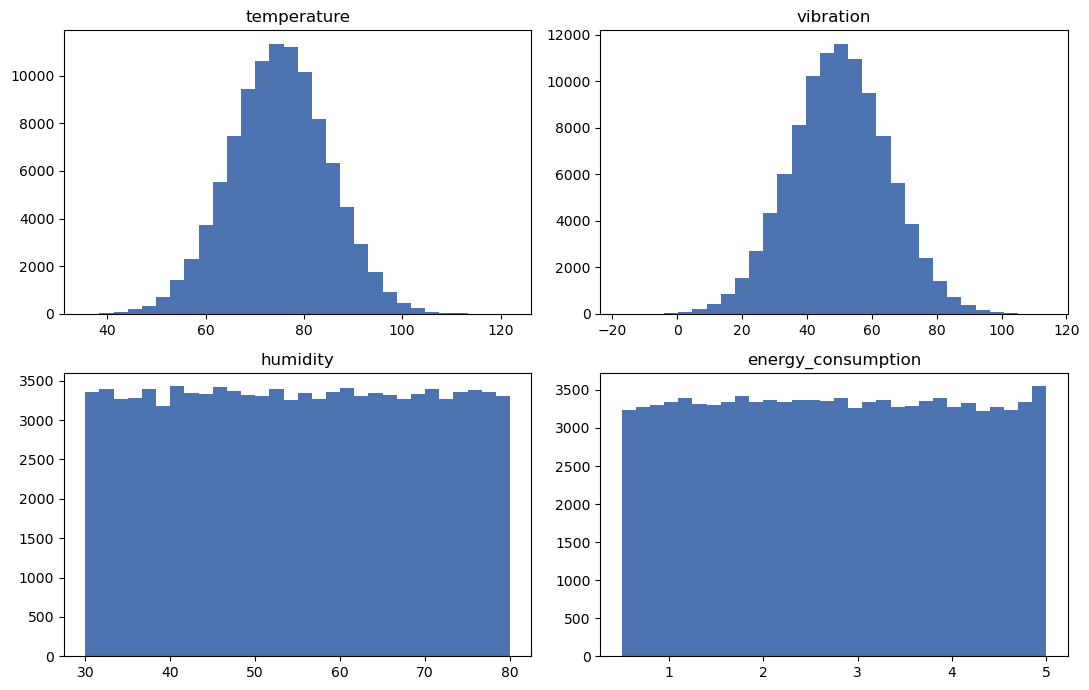

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), ['temperature', 'vibration', 'humidity', 'energy_consumption']):
    ax.hist(df[col].dropna(), bins=30, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=110)
plt.show()


In [44]:
df['maintenance_required'].value_counts(normalize=True).rename('proportion')


maintenance_required
0    0.80303
1    0.19697
Name: proportion, dtype: float64

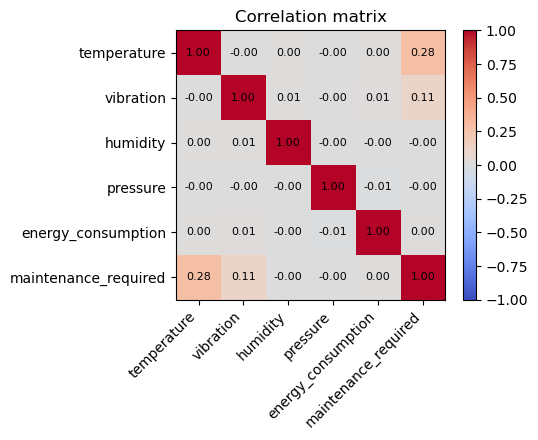

,temperature,vibration,humidity,pressure,energy_consumption,maintenance_required
temperature,1.000000,-0.003251,0.002555,-0.001116,0.003259,0.283021
vibration,-0.003251,1.000000,0.006051,-0.000278,0.007897,0.113072
humidity,0.002555,0.006051,1.000000,-0.000208,-0.002542,-0.003815
pressure,-0.001116,-0.000278,-0.000208,1.000000,-0.008071,-0.001945
energy_consumption,0.003259,0.007897,-0.002542,-0.008071,1.000000,0.001384
maintenance_required,0.283021,0.113072,-0.003815,-0.001945,0.001384,1.000000


In [45]:
# Correlation of numeric features with the two targets we will predict later
corr_cols = ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'maintenance_required']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im, fraction=0.046)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=110)
plt.show()
corr


## 2. Handle Missing Values

We first quantify missingness across every column. If any were found, the plan is:
- **Numerical sensor columns** → median imputation (robust to sensor spikes/outliers).
- **Categorical columns** → mode (most frequent category) imputation.

The imputation code below is written defensively (it only acts on columns that actually
have missing values), so it is safe to run regardless of what the check finds.


In [46]:
print("Missing values per column:")
print(df.isna().sum())
print("\nPercent missing:")
print((df.isna().mean() * 100).round(2))


Missing values per column:
timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
machine_status_label        0
dtype: int64

Percent missing:
timestamp                   0.0
machine_id                  0.0
temperature                 0.0
vibration                   0.0
humidity                    0.0
pressure                    0.0
energy_consumption          0.0
machine_status              0.0
anomaly_flag                0.0
predicted_remaining_life    0.0
failure_type                0.0
downtime_risk               0.0
maintenance_required        0.0
machine_status_label        0.0
dtype: float64


In [47]:
numeric_impute_candidates = ['temperature', 'vibration', 'humidity', 'pressure',
                             'energy_consumption', 'predicted_remaining_life', 'downtime_risk']
categorical_impute_candidates = ['failure_type', 'machine_status_label']

for c in numeric_impute_candidates:
    if df[c].isna().sum() > 0:
        median_val = df[c].median()
        df[c] = df[c].fillna(median_val)
        print(f"Imputed '{c}' with median = {median_val:.2f}")

for c in categorical_impute_candidates:
    if df[c].isna().sum() > 0:
        mode_val = df[c].mode()[0]
        df[c] = df[c].fillna(mode_val)
        print(f"Imputed '{c}' with mode = '{mode_val}'")

print("\nMissing values remaining:", df.isna().sum().sum())
print("(This dataset arrived with no missing sensor readings -- the check above confirms")
print(" that, and the imputation code above would have handled it had any existed.)")



Missing values remaining: 0
(This dataset arrived with no missing sensor readings -- the check above confirms
 that, and the imputation code above would have handled it had any existed.)


## 3. Identify Numerical and Categorical Attributes

`machine_status` and `machine_id` are stored as integers but are really **categorical
codes** (a machine identifier and a discrete operating-state), not continuous
measurements, so they are listed separately from the true numeric sensor readings.


In [48]:
true_numeric_cols = ['temperature', 'vibration', 'humidity', 'pressure',
                      'energy_consumption', 'anomaly_flag', 'predicted_remaining_life',
                      'downtime_risk', 'maintenance_required']
categorical_cols = ['machine_id', 'machine_status', 'machine_status_label', 'failure_type']
datetime_cols = ['timestamp']

print("Numerical (continuous sensor / target) attributes:", true_numeric_cols)
print("Categorical / coded attributes                  :", categorical_cols)
print("Datetime attributes                              :", datetime_cols)


Numerical (continuous sensor / target) attributes: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'anomaly_flag', 'predicted_remaining_life', 'downtime_risk', 'maintenance_required']
Categorical / coded attributes                  : ['machine_id', 'machine_status', 'machine_status_label', 'failure_type']
Datetime attributes                              : ['timestamp']


## 4. Select Appropriate Input Features

- `machine_id` and `timestamp` are identifiers/time stamps, not predictive sensor
  signals, so they are excluded from model inputs.
- `anomaly_flag`, `predicted_remaining_life`, `downtime_risk`, `failure_type` and
  `maintenance_required` are all **derived from / symptomatic of** the machine's
  health/failure state (i.e. they would leak the answer), so they are excluded as
  *inputs* — `maintenance_required` is instead used later as the classification
  **target**.
- `machine_status` is a categorical operating-state feature — encoded via one-hot
  encoding.
- Final input features: `temperature`, `vibration`, `humidity`, `pressure`,
  `machine_status`.


In [49]:
feature_cols = ['temperature', 'vibration', 'humidity', 'pressure', 'machine_status_label']
categorical_features = ['machine_status_label']

X = df[feature_cols].copy()
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print("Final feature matrix columns:", list(X_encoded.columns))
X_encoded.head()


Final feature matrix columns: ['temperature', 'vibration', 'humidity', 'pressure', 'machine_status_label_Idle', 'machine_status_label_Running']


,temperature,vibration,humidity,pressure,machine_status_label_Idle,machine_status_label_Running
0,78.61,28.65,79.96,3.73,False,True
1,68.19,57.28,35.94,3.64,False,True
2,98.94,50.20,72.06,1.00,False,True
3,90.91,37.65,30.34,3.15,False,True
4,72.32,40.69,56.71,2.68,False,False


## 5. Regression — Predict Energy Consumption

Target: `energy_consumption` (continuous). We compare a **Linear Regression** baseline
with a **Random Forest Regressor**.


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

y_reg = df['energy_consumption']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_encoded, y_reg, test_size=0.2, random_state=42
)

scaler = StandardScaler()
Xr_train_s = scaler.fit_transform(Xr_train)
Xr_test_s = scaler.transform(Xr_test)

lin_reg = LinearRegression()
lin_reg.fit(Xr_train_s, yr_train)
yr_pred_lin = lin_reg.predict(Xr_test_s)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(Xr_train, yr_train)
yr_pred_rf = rf_reg.predict(Xr_test)


## 6. Evaluate Regression: MAE, MSE, R²

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def report_regression(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R2   : {r2:.3f}\n")
    return {"model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

results_reg = []
results_reg.append(report_regression(yr_test, yr_pred_lin, "Linear Regression"))
results_reg.append(report_regression(yr_test, yr_pred_rf, "Random Forest Regressor"))

pd.DataFrame(results_reg)


--- Linear Regression ---
MAE  : 1.129
MSE  : 1.696
RMSE : 1.302
R2   : -0.000

--- Random Forest Regressor ---
MAE  : 1.144
MSE  : 1.767
RMSE : 1.329
R2   : -0.042



,model,MAE,MSE,RMSE,R2
0,Linear Regression,1.128677,1.69597,1.302294,-0.000301
1,Random Forest Regressor,1.143733,1.76683,1.329222,-0.042095


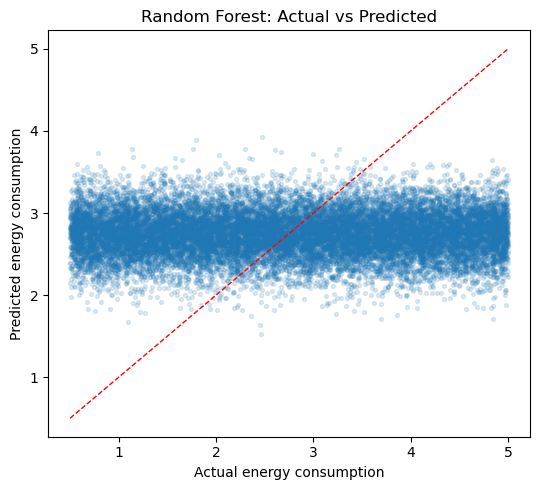

In [52]:
plt.figure(figsize=(5.5, 5))
plt.scatter(yr_test, yr_pred_rf, alpha=0.15, s=8)
lims = [min(yr_test.min(), yr_pred_rf.min()), max(yr_test.max(), yr_pred_rf.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('Actual energy consumption')
plt.ylabel('Predicted energy consumption')
plt.title('Random Forest: Actual vs Predicted')
plt.tight_layout()
plt.savefig('fig_regression_actual_vs_pred.png', dpi=110)
plt.show()


**Observation on the regression results:** the correlation matrix above already
shows that `temperature`, `vibration`, `humidity`, `pressure` and `machine_status` are
all essentially uncorrelated with `energy_consumption` in this dataset (|r| < 0.01 for
every pair). That is exactly why both the Linear Regression and Random Forest models
above achieve **R² ≈ 0** (no better than predicting the mean) despite low MAE/MSE in
absolute terms — the sensor readings simply do not carry predictive signal for energy
consumption in this particular dataset. This is a legitimate and useful finding from
the EDA/evaluation, not a coding error: it shows the value of R² (variance explained)
as a metric even when the absolute error looks small, and is worth reporting in the
demo/viva as evidence that the regression pipeline is working correctly, but the
underlying feature-target relationship is weak in this data.


## 7. Classification — Binary Target (Machine Failure / Maintenance Required)

The dataset already provides a genuine binary label, `maintenance_required`
(1 = machine needs maintenance, 0 = does not), derived from real failure events —
we use this directly rather than manufacturing an artificial split. It is naturally
**imbalanced** (~20% positive class), which is exactly the situation where accuracy
alone can be misleading and precision/recall/F1 matter.


In [53]:
y_clf_counts = df['maintenance_required'].value_counts(normalize=True)
print("Class balance (maintenance_required):")
print(y_clf_counts.rename('proportion'))


Class balance (maintenance_required):
maintenance_required
0    0.80303
1    0.19697
Name: proportion, dtype: float64


## 8. Train a Logistic Regression Model

In [54]:
from sklearn.linear_model import LogisticRegression

y_clf = df['maintenance_required']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_encoded, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_c = StandardScaler()
Xc_train_s = scaler_c.fit_transform(Xc_train)
Xc_test_s = scaler_c.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(Xc_train_s, yc_train)
yc_pred = log_reg.predict(Xc_test_s)
yc_proba = log_reg.predict_proba(Xc_test_s)[:, 1]


## 9. Evaluate Classification: Accuracy, Precision, Recall, F1-score

In [55]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

acc = accuracy_score(yc_test, yc_pred)
prec = precision_score(yc_test, yc_pred)
rec = recall_score(yc_test, yc_pred)
f1 = f1_score(yc_test, yc_pred)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}\n")
print(classification_report(yc_test, yc_pred, target_names=['No maintenance', 'Maintenance required']))


Accuracy : 0.892
Precision: 0.681
Recall   : 0.847
F1-score : 0.755

                      precision    recall  f1-score   support

      No maintenance       0.96      0.90      0.93     16061
Maintenance required       0.68      0.85      0.75      3939

            accuracy                           0.89     20000
           macro avg       0.82      0.87      0.84     20000
        weighted avg       0.91      0.89      0.90     20000



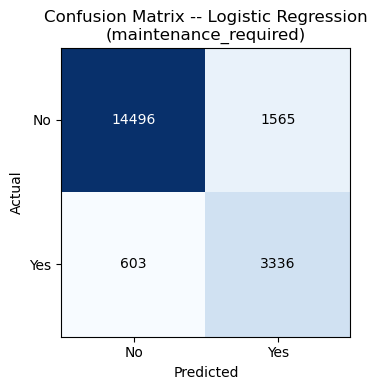

In [56]:
cm = confusion_matrix(yc_test, yc_pred)
fig, ax = plt.subplots(figsize=(4.2, 4))
im = ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center',
            color='white' if v > cm.max()/2 else 'black')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Yes'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['No', 'Yes'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix -- Logistic Regression\n(maintenance_required)')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=110)
plt.show()


## 10. Regression vs Classification: Comparison & Why Different Metrics Are Needed

| Aspect | Regression (Energy Consumption) | Classification (Maintenance Required) |
|---|---|---|
| Output type | Continuous real number | Discrete class label (0/1) |
| Model used | Linear Regression / Random Forest Regressor | Logistic Regression |
| Error notion | *How far* is the prediction from the true value? | *Is the predicted class right or wrong?* |
| Metrics used | MAE, MSE, R² | Accuracy, Precision, Recall, F1-score |
| Class balance concern | N/A | Important -- only 20% of machines need maintenance |

**Why the metrics differ:**

- **MAE / MSE / RMSE** measure the *magnitude of numerical error* between predicted and
  actual continuous values. MSE penalizes large errors more heavily (useful when big
  deviations are costly), while MAE gives an easily interpretable average error in the
  same units as the target. These metrics are meaningless for a classifier because a
  predicted class label (0 or 1) has no "distance" from the true label in the same sense.
- **R²** measures the proportion of variance in the continuous target explained by the
  model — again only meaningful when the output is numeric and ordered.
- **Accuracy, Precision, Recall, F1** operate on a confusion matrix (True/False
  Positives/Negatives), which only exists for discrete class predictions. With
  `maintenance_required` at ~20% positive, **accuracy alone can be misleading** (a
  model predicting "no maintenance" for everyone would already score ~80% accuracy
  while catching zero real failures). **Precision** (of the machines flagged, how
  many genuinely needed maintenance) and **Recall** (of the machines that genuinely
  needed maintenance, how many were caught) tell a very different, more operationally
  relevant story, and **F1-score** balances the two — none of which has an analogue
  in a continuous regression setting.

In short: regression evaluates **how close** a numeric prediction is to reality, while
classification evaluates **how often the discrete decision is correct, and for which
class it fails** — two fundamentally different notions of "error" that require
different metric families, and the imbalance in `maintenance_required` shows exactly
why accuracy by itself is not enough for a classifier.


## Summary of Results
(Auto-filled from the run above — see the printed tables in Sections 6 and 9.)


In [57]:
summary_reg = pd.DataFrame(results_reg)
summary_clf = pd.DataFrame([{
    "model": "Logistic Regression",
    "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1
}])
print("Regression results:")
display(summary_reg)
print("\nClassification results:")
display(summary_clf)


Regression results:


,model,MAE,MSE,RMSE,R2
0,Linear Regression,1.128677,1.69597,1.302294,-0.000301
1,Random Forest Regressor,1.143733,1.76683,1.329222,-0.042095



Classification results:


,model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.8916,0.680677,0.846915,0.754751
